# 01 — Seaborn Basics, Relational Plots & Figure Aesthetics
**Preetham's Seaborn Mastery Series**

Seaborn is a Python data visualization library built on top of Matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics.

### Notebook Contents:
1. **Seaborn Setup & Dataset Loading**
2. **Themes & Aesthetics (`sns.set_theme`, `sns.set_style`)**
3. **Removing Spines (`sns.despine`)**
4. **Context Scaling (`sns.set_context`)**
5. **Color Palettes & Custom Palettes (`sns.color_palette`, `sns.diverging_palette`, `sns.cubehelix_palette`)**
6. **Scatter Plots (`sns.scatterplot`) — Multidimensional Encodings**
7. **Line Plots (`sns.lineplot`) — Time Series & Confidence Intervals**
8. **Figure-Level Relational Plots (`sns.relplot`) — Faceting Across Rows & Columns**
9. **Figure-Level vs Axes-Level API Architecture Deep Dive**
10. **Summary & Key Takeaways**


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set default aesthetic settings
sns.set_theme(style="whitegrid")
%matplotlib inline

print("Seaborn Version:", sns.__version__)

# Load benchmark datasets
tips = sns.load_dataset("tips")
fmri = sns.load_dataset("fmri")
penguins = sns.load_dataset("penguins")

print("Tips sample:")
print(tips.head())


Seaborn Version: 0.13.2
Tips sample:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


## 1. Figure Themes & Built-in Styles (`sns.set_style`)

Seaborn comes with five preset Matplotlib themes:
- `darkgrid` (default)
- `whitegrid`
- `dark`
- `white`
- `ticks`

Let's visualize the same plot across all 5 styles.


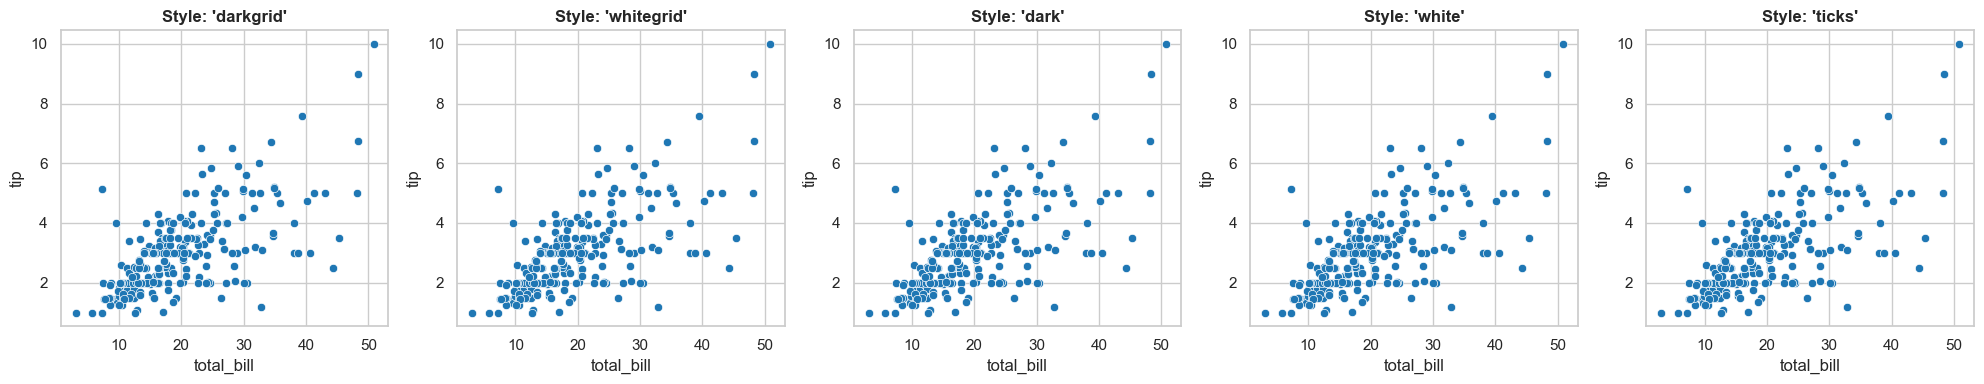

In [2]:
styles = ["darkgrid", "whitegrid", "dark", "white", "ticks"]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, style in zip(axes, styles):
    sns.set_style(style)
    sns.scatterplot(data=tips, x="total_bill", y="tip", ax=ax, color="#1f77b4")
    ax.set_title(f"Style: '{style}'", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Reset theme back to whitegrid
sns.set_theme(style="whitegrid")


## 2. Removing Axis Spines (`sns.despine`)

The `sns.despine()` function allows you to remove top and right spines (or all outer borders) for a cleaner, modern look.


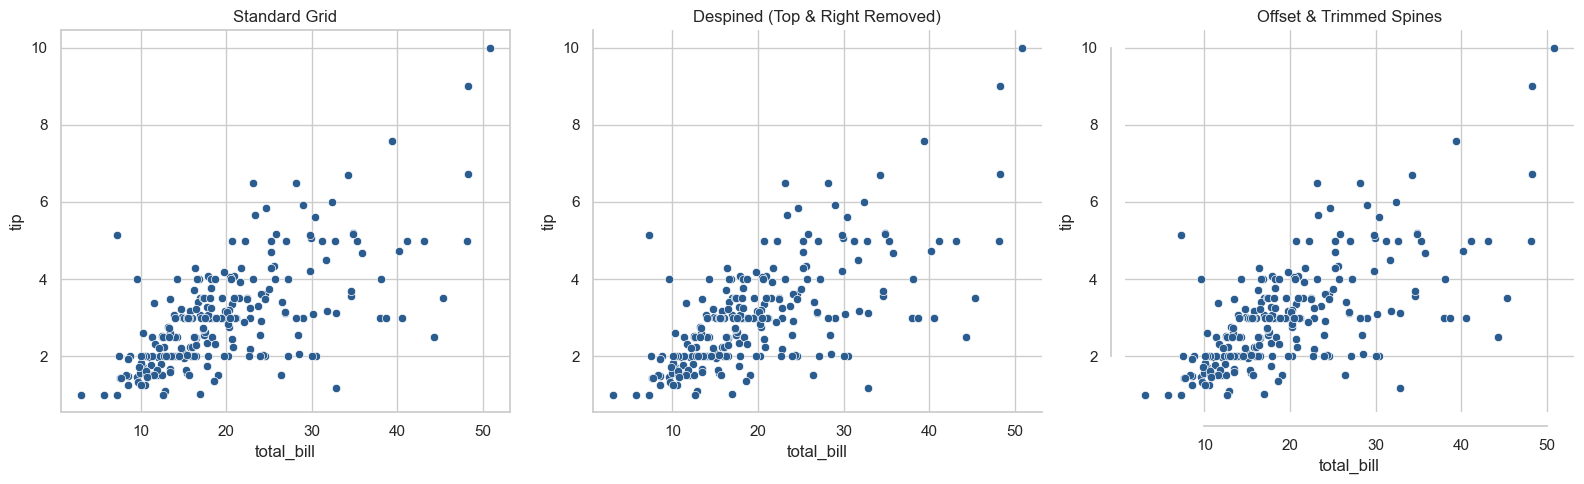

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Standard
sns.scatterplot(data=tips, x="total_bill", y="tip", ax=axes[0], color="#2b5c8f")
axes[0].set_title("Standard Grid")

# Plot 2: Despined (Top & Right)
sns.scatterplot(data=tips, x="total_bill", y="tip", ax=axes[1], color="#2b5c8f")
sns.despine(ax=axes[1])
axes[1].set_title("Despined (Top & Right Removed)")

# Plot 3: Offset Spines & Trimmed
sns.scatterplot(data=tips, x="total_bill", y="tip", ax=axes[2], color="#2b5c8f")
sns.despine(ax=axes[2], offset=10, trim=True)
axes[2].set_title("Offset & Trimmed Spines")

plt.tight_layout()
plt.show()


## 3. Scaling Plot Elements (`sns.set_context`)

Seaborn lets you automatically scale font sizes and line widths for different media formats using `sns.set_context()`:
- `paper` (smallest, for journal articles)
- `notebook` (default)
- `talk` (larger fonts for slide presentations)
- `poster` (largest font sizes)


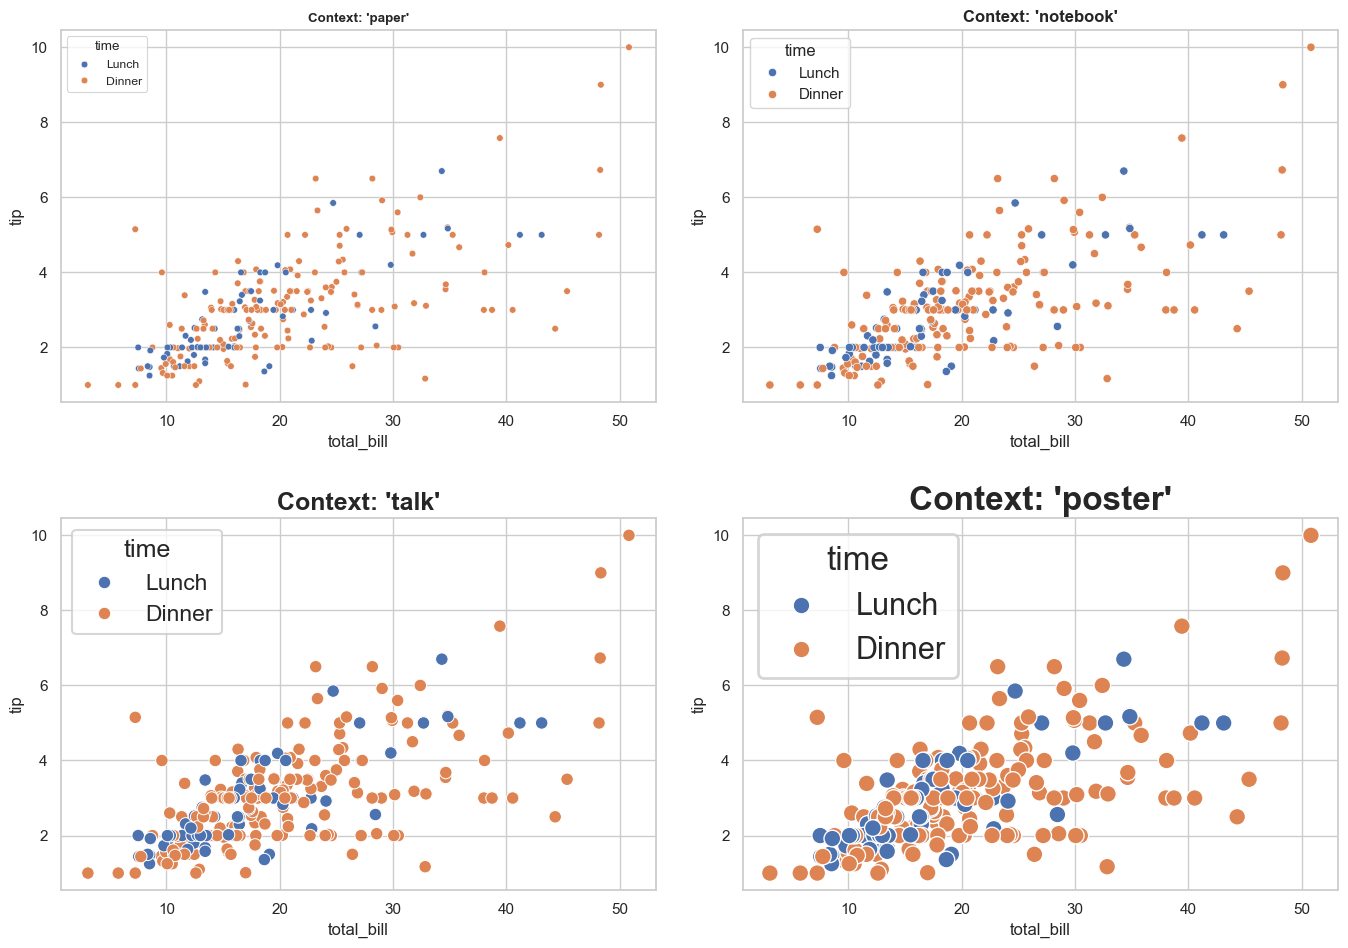

In [4]:
contexts = ["paper", "notebook", "talk", "poster"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, context in zip(axes, contexts):
    sns.set_context(context)
    sns.scatterplot(data=tips, x="total_bill", y="tip", hue="time", ax=ax)
    ax.set_title(f"Context: '{context}'", fontweight='bold')

plt.tight_layout()
plt.show()

# Reset context back to notebook
sns.set_context("notebook")


## 4. Masterclass on Seaborn Color Palettes

Seaborn offers rich color palette capabilities:
1. **Qualitative palettes** (`deep`, `muted`, `pastel`, `bright`, `dark`, `colorblind`)
2. **Sequential palettes** (`Blues`, `viridis`, `rocket`, `mako`, `flare`, `crest`)
3. **Diverging palettes** (`vlag`, `coolwarm`, `Spectral`, custom `sns.diverging_palette`)
4. **Perceptually uniform palettes** (`sns.cubehelix_palette`)


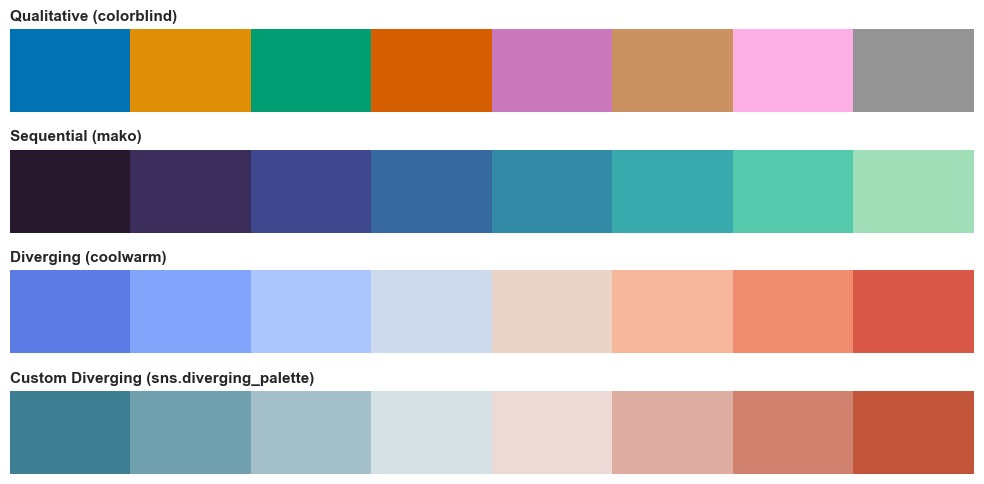

In [5]:
# Display custom palette previews
palettes = [
    ("Qualitative (colorblind)", sns.color_palette("colorblind", 8)),
    ("Sequential (mako)", sns.color_palette("mako", 8)),
    ("Diverging (coolwarm)", sns.color_palette("coolwarm", 8)),
    ("Custom Diverging (sns.diverging_palette)", sns.diverging_palette(220, 20, as_cmap=False, n=8)),
]

fig, axes = plt.subplots(len(palettes), 1, figsize=(10, 5))
for ax, (name, pal) in zip(axes, palettes):
    ax.imshow([pal], aspect="auto")
    ax.set_axis_off()
    ax.set_title(name, fontsize=11, loc="left", fontweight="bold")

plt.tight_layout()
plt.show()


## 5. Scatter Plots (`sns.scatterplot`) — Multidimensional Encoding

`scatterplot()` visualizes the relationship between two continuous variables, with support for additional dimensions via:
- `hue`: Color mapping (categorical or numeric)
- `style`: Marker shape mapping
- `size` & `sizes`: Marker size mapping
- `alpha`: Transparency control


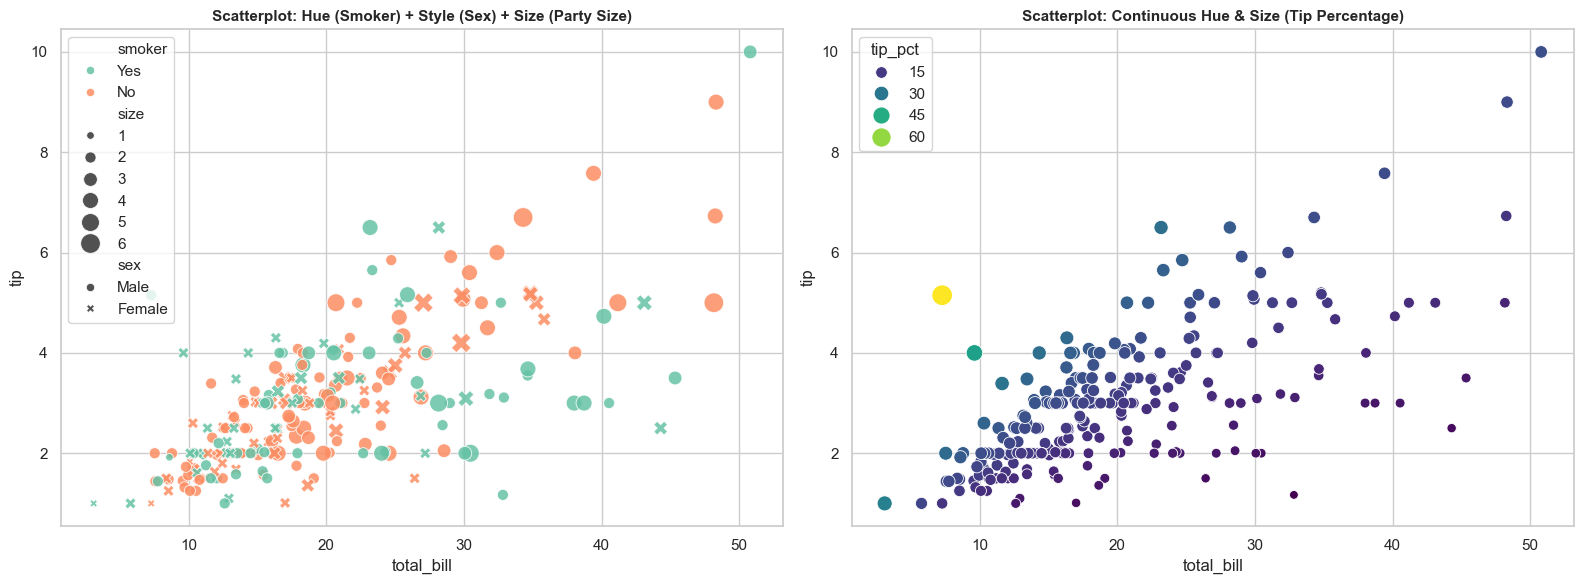

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 3D Mapping: Total Bill vs Tip by Smoker (Hue) and Sex (Style)
sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="smoker",
    style="sex",
    size="size",
    sizes=(30, 200),
    palette="Set2",
    alpha=0.85,
    ax=axes[0]
)
axes[0].set_title("Scatterplot: Hue (Smoker) + Style (Sex) + Size (Party Size)", fontsize=11, fontweight="bold")

# Numeric Hue Mapping: Tip percentage & Continuous Palette
tips_df = tips.copy()
tips_df['tip_pct'] = (tips_df['tip'] / tips_df['total_bill']) * 100

sns.scatterplot(
    data=tips_df,
    x="total_bill",
    y="tip",
    hue="tip_pct",
    palette="viridis",
    size="tip_pct",
    sizes=(40, 220),
    ax=axes[1]
)
axes[1].set_title("Scatterplot: Continuous Hue & Size (Tip Percentage)", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()


## 6. Line Plots (`sns.lineplot`) — Time Series & Error Intervals

`lineplot()` automatically computes mean values and continuous confidence intervals (95% CI by default) across multiple observations per x-value.


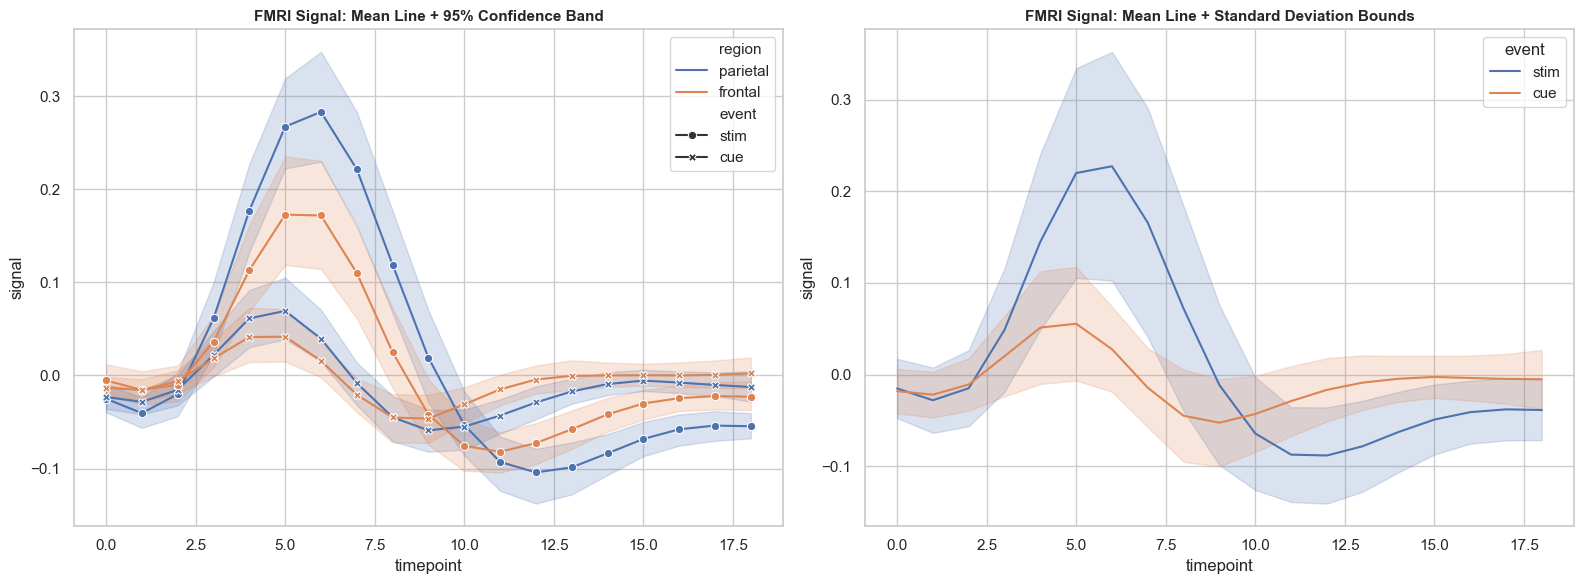

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: FMRI Signal over Time across Regions & Events
sns.lineplot(
    data=fmri,
    x="timepoint",
    y="signal",
    hue="region",
    style="event",
    markers=True,
    dashes=False,
    err_style="band",
    palette="deep",
    ax=axes[0]
)
axes[0].set_title("FMRI Signal: Mean Line + 95% Confidence Band", fontsize=11, fontweight="bold")

# Plot 2: Lineplot with Standard Deviation Error Bars
sns.lineplot(
    data=fmri,
    x="timepoint",
    y="signal",
    hue="event",
    errorbar="sd",
    ax=axes[1]
)
axes[1].set_title("FMRI Signal: Mean Line + Standard Deviation Bounds", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()


## 7. Figure-Level Relational Plot (`sns.relplot`)

`relplot()` is a figure-level interface that combines `scatterplot()` and `lineplot()` with powerful `FacetGrid` subplots across categorical rows and columns.


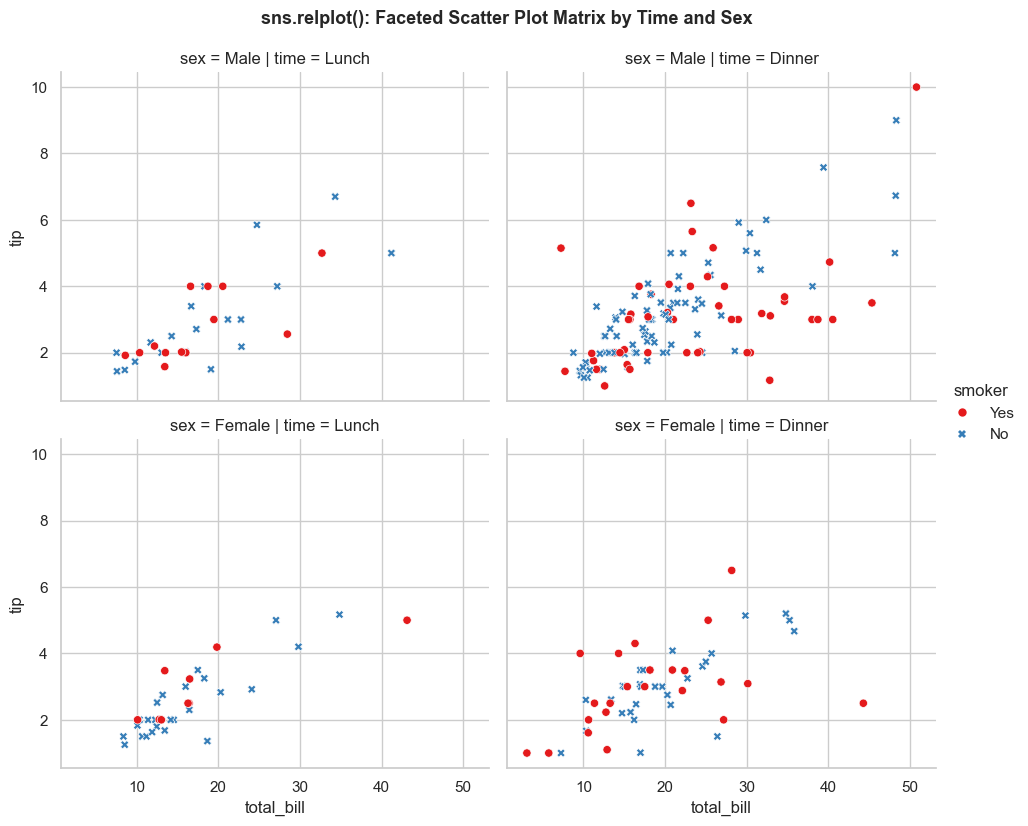

In [8]:
# Figure-Level Faceted Relational Plot
g = sns.relplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="smoker",
    style="smoker",
    col="time",
    row="sex",
    height=4,
    aspect=1.2,
    palette="Set1"
)
g.fig.suptitle("sns.relplot(): Faceted Scatter Plot Matrix by Time and Sex", y=1.03, fontsize=13, fontweight="bold")
plt.show()


## 8. Figure-Level vs Axes-Level Architecture Comparison

Seaborn functions fall into two architecture categories:
1. **Axes-Level Functions**: (`scatterplot`, `lineplot`, `barplot`, `histplot`, etc.) draw onto a specific Matplotlib `ax`. Perfect for custom subplot grids (`plt.subplots`).
2. **Figure-Level Functions**: (`relplot`, `catplot`, `displot`, `lmplot`) create and manage their own Matplotlib figure (`FacetGrid`). They control row/column faceting natively.

Let's see them side-by-side:


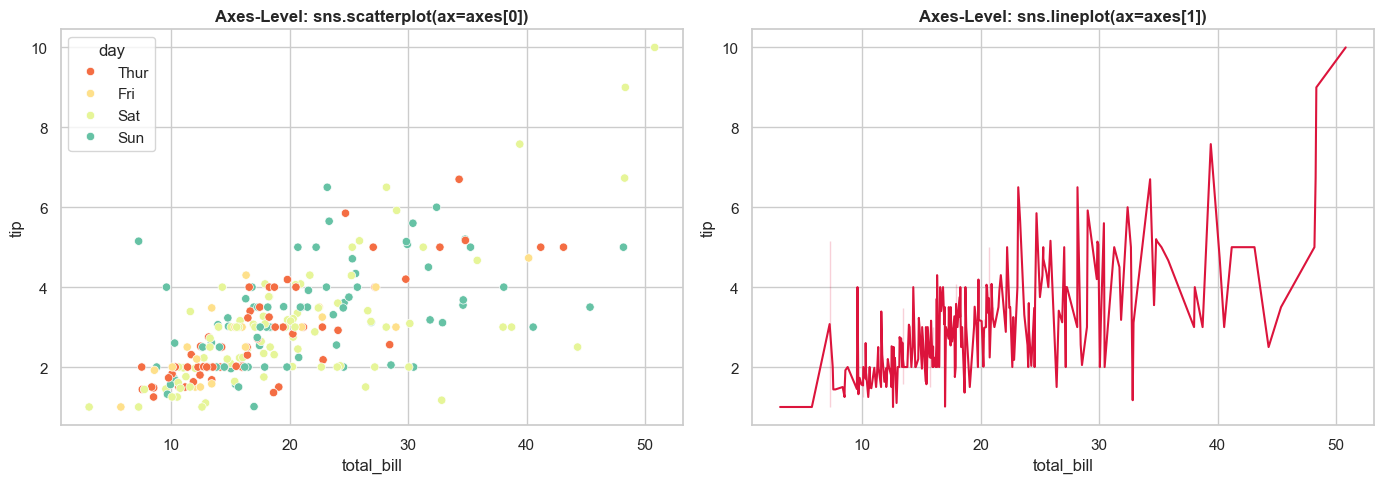

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Axes-Level Example: Drawing directly onto subplot axis
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="day", ax=axes[0], palette="Spectral")
axes[0].set_title("Axes-Level: sns.scatterplot(ax=axes[0])", fontweight="bold")

sns.lineplot(data=tips, x="total_bill", y="tip", ax=axes[1], color="crimson")
axes[1].set_title("Axes-Level: sns.lineplot(ax=axes[1])", fontweight="bold")

plt.tight_layout()
plt.show()


## 9. Summary & Key Takeaways

In this notebook, we mastered:
- Styling plots with `sns.set_theme()`, `sns.set_style()`, `sns.despine()`, and `sns.set_context()`.
- Building custom palettes using qualitative, sequential, and diverging color spaces.
- Visualizing multi-variable relational data using `scatterplot()` and `lineplot()`.
- Leveraging figure-level faceting via `relplot()`.
- Understanding the difference between Axes-level and Figure-level Seaborn APIs.
